# Taller 1 — Procesamiento de datasets, tokenizadores y embeddings (semántica vectorial)

**Maestría Virtual en Ingeniería de Sistemas y Computación · PLN · ACT_7**

Notebook **único** con los tres puntos del taller. Pensado para **Google Colab / Kaggle con GPU**.

| Punto | Tema | Herramientas |
|---|---|---|
| **1** | Embeddings de palabras sobre `spanish_billion_words` | Word2Vec + FastText (Gensim) |
| **2** | Tokenización del dataset **BioBERT** (local) | BETO (`dccuchile/bert-base-spanish-wwm-cased`) |
| **3** | Embeddings de oraciones sobre PDFs | `pymupdf4llm` + LangChain + `sentence-transformers` |

> **Antes de correr:**
> - Runtime con **GPU** (Punto 3 lo agradece; el Punto 1 usa CPU).
> - Sube a tu Drive la carpeta de la actividad en `MyDrive/PLN/ACT_7/` con:
>   - `Biobert/` (que contiene `Biobert_json.py` y `data56/{train,valid,test}.json`)
>   - `pdf-coding/` (los PDFs)

## 0. Configuración del entorno

In [2]:
# 0.1  Instalación de librerías (una vez por sesión)
!pip install -q -U gensim nltk datasets transformers sentence-transformers
!pip install -q -U pymupdf4llm langchain langchain-community pypdf

Listo. Si Colab lo pide, reinicia el entorno tras instalar.


In [3]:
# 0.2  Montar Drive y definir rutas (mismo esquema que las otras actividades)
import os
from google.colab import drive
# drive.mount('/content/drive')
drive.mount('/content/drive', force_remount=True)

BASE_DIR   = '/content/drive/MyDrive/PLN/ACT_7'
BIOBERT_DIR = os.path.join(BASE_DIR, 'Biobert')      # contiene Biobert_json.py y data56/
PDF_DIR     = os.path.join(BASE_DIR, 'pdf-coding')   # PDFs para el punto 3
MODELS_DIR  = os.path.join(BASE_DIR, 'models')       # modelos de embeddings entrenados
os.makedirs(MODELS_DIR, exist_ok=True)

for p in [BASE_DIR, BIOBERT_DIR, PDF_DIR]:
    print(f'{p}  ->  {"OK" if os.path.exists(p) else "NO EXISTE (súbelo a Drive)"}')

Mounted at /content/drive
/content/drive/MyDrive/PLN/ACT_7  ->  OK
/content/drive/MyDrive/PLN/ACT_7/Biobert  ->  OK
/content/drive/MyDrive/PLN/ACT_7/pdf-coding  ->  OK


In [4]:
# 0.3  Semilla y dispositivo
import numpy as np, random
try:
    import torch
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
except Exception:
    device = 'cpu'
random.seed(42); np.random.seed(42)
print('Dispositivo:', device)

Dispositivo: cpu


---
# Punto 1 — Embeddings de palabras (Word2Vec y FastText con Gensim)

Sobre `spanish_billion_words` entrenamos **Word2Vec** y **FastText** y comparamos.

## 1.1  Preprocesamiento del dataset

Cargamos el corpus y para cada sentencia: minúsculas, **quitar números**, **quitar
puntuación/símbolos**, **quitar stopwords en español** y **tokenizar**. El resultado es una
**lista de listas** de tokens limpios (formato de entrada de Gensim).

In [5]:
# 1.1  Carga del corpus y limpieza -> lista de listas de tokens
import re
from datasets import load_dataset
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
STOP_ES = set(stopwords.words('spanish'))

# Corpus en español limpio (mismo que se usó en ACT_1). Streaming para no agotar RAM.
ds_stream = load_dataset('jhonparra18/spanish_billion_words_clean', split='train', streaming=True)

def limpiar(texto):
    texto = texto.lower()
    texto = re.sub(r'\d+', ' ', texto)               # eliminar números
    texto = re.sub(r'[^a-záéíóúñü\s]', ' ', texto)   # solo letras del español
    tokens = texto.split()
    return [t for t in tokens if t not in STOP_ES and len(t) > 2]

def construir_corpus(n_sentencias):
    '''Devuelve una lista de listas de tokens limpios con n_sentencias del corpus.'''
    corpus = []
    for i, ejemplo in enumerate(ds_stream):
        if i >= n_sentencias:
            break
        toks = limpiar(ejemplo['text'])
        if toks:
            corpus.append(toks)
    return corpus

# Ejemplo pequeño para verificar el preprocesamiento
demo = construir_corpus(5)
print('Primeras sentencias tokenizadas y limpias:')
for s in demo[:3]:
    print(' ', s[:15], '...')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

Primeras sentencias tokenizadas y limpias:
  ['source', 'wikisource', 'librodot', 'com', 'sensibilidad', 'jane', 'austen', 'capitulo'] ...
  ['familia', 'dashwood', 'llevaba', 'largo', 'tiempo', 'afincada', 'sussex'] ...
  ['propiedad', 'buen', 'tamaño', 'centro', 'encontraba', 'residencia', 'norland', 'park', 'manera', 'tan', 'digna', 'vivido', 'muchas', 'generaciones', 'llegó'] ...


## 1.2  Entrenamiento de los modelos

Según el taller: **Word2Vec** y **FastText** con embeddings de **100, 200 y 300** y tamaños de
corpus de **500 000, 5 M y 10 M** de sentencias.

> ⚠️ **Tiempo/RAM:** 5 M y 10 M de sentencias son muy pesados. Por esto se inicia con `500_000` para validar
> y sube según tu Colab (Pro/High-RAM para 5–10 M). Cada modelo se guarda en Drive para no reentrenar.

In [7]:
# 1.2  Entrenamiento práctico: corpus de 500k, dims 100/200/300 (Word2Vec y FastText)
from gensim.models import Word2Vec, FastText
import time

N = 500_000
print(f'Construyendo corpus de {N:,} sentencias (una sola vez)...')
corpus = construir_corpus(N)
print('Sentencias limpias:', len(corpus))

modelos = {}
for algo, Clase in [('w2v', Word2Vec), ('ft', FastText)]:
    for dim in (100, 200, 300):
        t0 = time.time()
        m = Clase(sentences=corpus, vector_size=dim, window=5, min_count=5,
                  workers=4, sg=1, epochs=5)
        m.save(os.path.join(MODELS_DIR, f'{algo}_dim{dim}_n{N}.model'))
        modelos[f'{algo}_{dim}'] = m
        print(f'[{algo}] dim={dim} | vocab={len(m.wv):,} | {time.time()-t0:.0f}s')

w2v_300, ft_300 = modelos['w2v_300'], modelos['ft_300']
print('(6 modelos entrenados)')

Construyendo corpus de 500,000 sentencias (una sola vez)...
Sentencias limpias: 499878
[w2v] dim=100 | vocab=61,968 | 270s
[w2v] dim=200 | vocab=61,968 | 262s
[w2v] dim=300 | vocab=61,968 | 326s
[ft] dim=100 | vocab=61,968 | 507s
[ft] dim=200 | vocab=61,968 | 801s
[ft] dim=300 | vocab=61,968 | 1044s
(6 modelos entrenados)


## 1.3  Consulta de similitud semántica (top-10 en AMBOS modelos)

Función que, dada una palabra, devuelve las **10 palabras más similares** en Word2Vec **y** en
FastText, para poder compararlos.

In [8]:
# 1.3  Top-10 palabras más similares en ambos modelos
import pandas as pd

def similares(palabra, modelo_w2v=w2v_300, modelo_ft=ft_300, topn=10):
    palabra = palabra.lower()
    def _top(m):
        if palabra in m.wv:
            return [(w, round(s, 4)) for w, s in m.wv.most_similar(palabra, topn=topn)]
        return [('(fuera de vocab)', 0.0)]
    w2v = _top(modelo_w2v)
    # FastText sí maneja palabras fuera de vocabulario (subword)
    ft = [(w, round(s, 4)) for w, s in modelo_ft.wv.most_similar(palabra, topn=topn)]
    tabla = pd.DataFrame({'Word2Vec': [f'{w} ({s})' for w, s in w2v],
                          'FastText': [f'{w} ({s})' for w, s in ft]})
    tabla.index = [f'#{i+1}' for i in range(len(tabla))]
    print(f'Palabras más similares a: "{palabra}"')
    return tabla

similares('rey')

Palabras más similares a: "rey"


,Word2Vec,FastText
#1,benjamín (0.6879),reyes (0.6949)
#2,mosíah (0.6855),reinó (0.6797)
#3,limhi (0.6751),rehusó (0.6658)
#4,ungido (0.6735),rebuzno (0.6607)
#5,ammón (0.6628),rebeló (0.6597)
#6,nabucodonosor (0.6605),rezo (0.6445)
#7,lamoni (0.6562),mosíah (0.6439)
#8,lamán (0.6525),regocijó (0.6413)
#9,sedequías (0.6484),reír (0.6404)
#10,judá (0.6475),rebaño (0.6332)


**¿Cuál es el mejor modelo?** *FastText* suele ganar porque construye vectores a partir de
**subpalabras (n-gramas de caracteres)**, así que maneja palabras raras, morfología rica y
términos fuera de vocabulario (OOV) — muy útil en español. *Word2Vec* es más rápido y puede ser
suficiente si el vocabulario está bien cubierto. *(Sustituye por tu conclusión con ejemplos.)*

## 1.4  Visualización con PCA / t-SNE

Proyectamos los embeddings **de tamaño 300** al plano para **50, 100 y 300** sentencias y
comparamos Word2Vec vs. FastText.

Resolving data files:   0%|          | 0/18 [00:00<?, ?it/s]

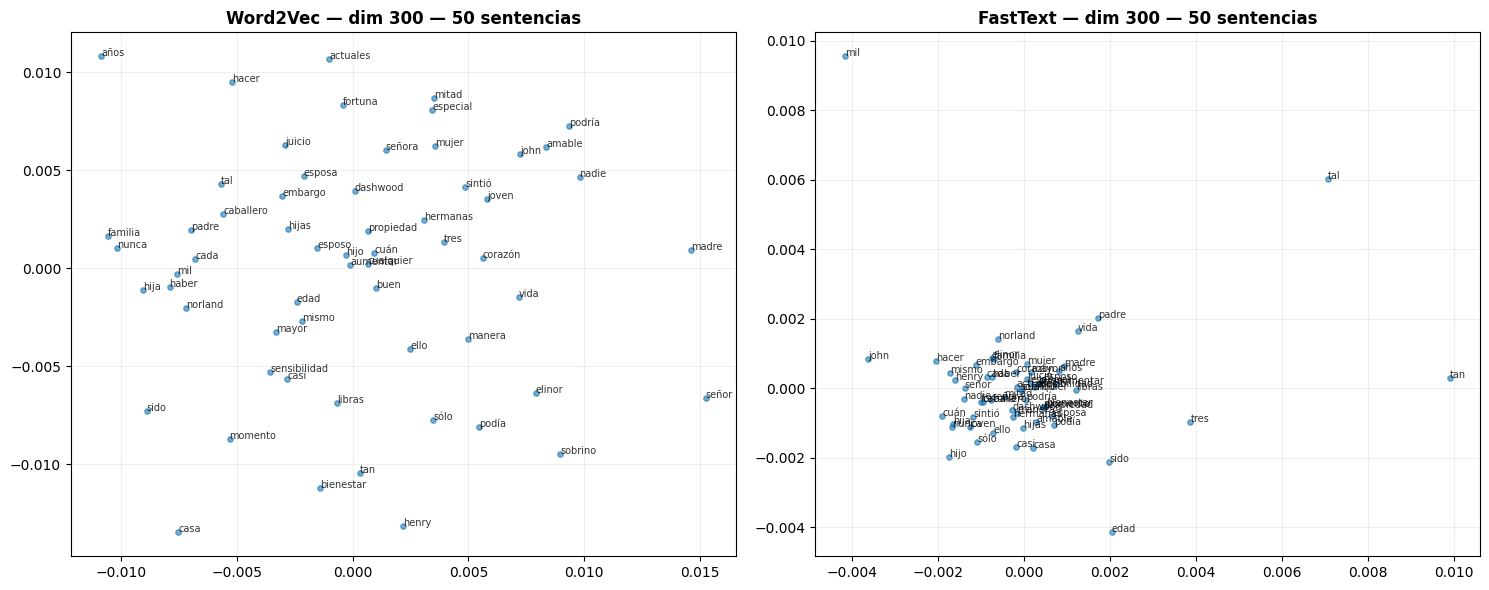

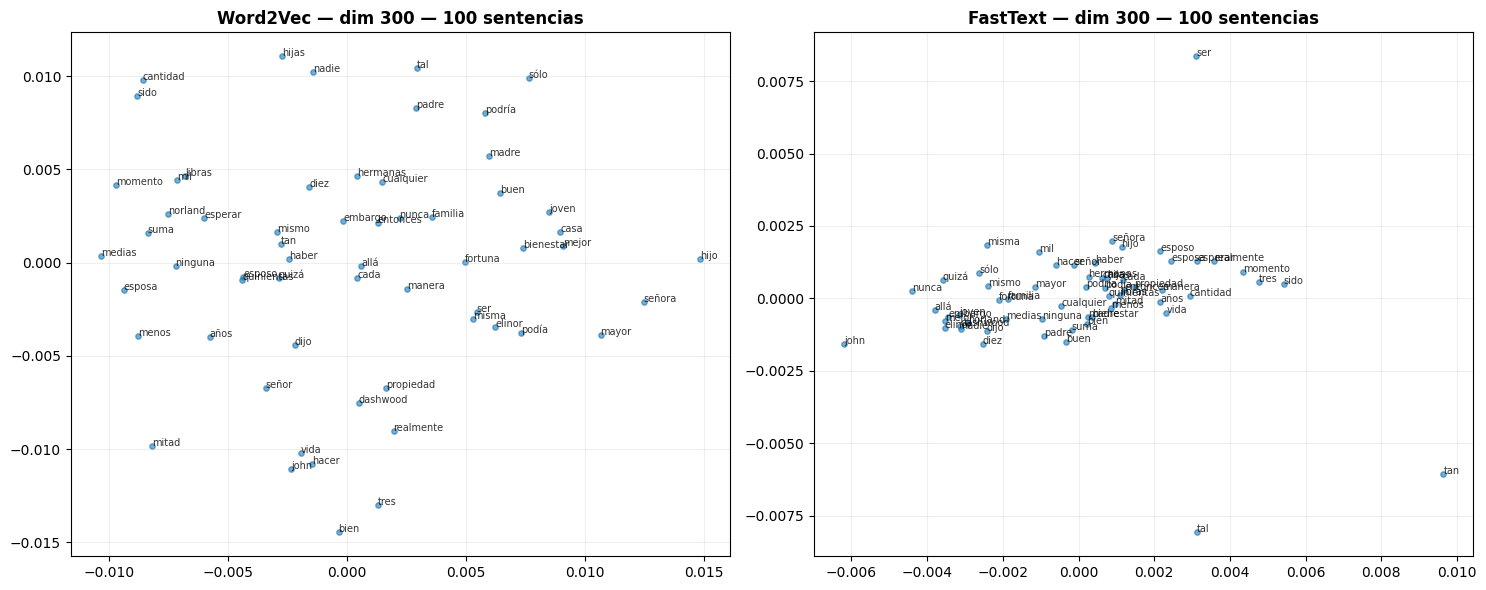

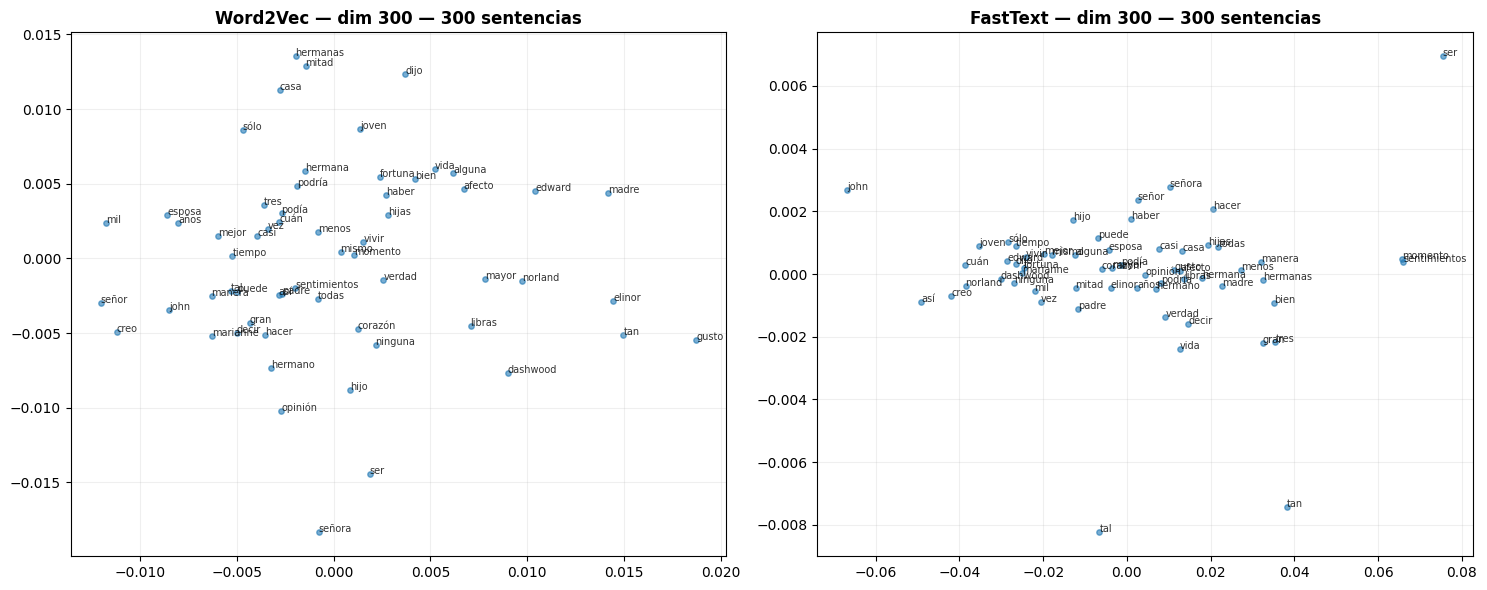

In [5]:
# 1.4  Visualización 2D (PCA) — AUTOCONTENIDA
import re
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from datasets import load_dataset
from gensim.models import Word2Vec, FastText
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
STOP_ES = set(stopwords.words('spanish'))

_ds = load_dataset('jhonparra18/spanish_billion_words_clean', split='train', streaming=True)

def _limpiar(t):
    t = t.lower()
    t = re.sub(r'\d+', ' ', t)
    t = re.sub(r'[^a-záéíóúñü\s]', ' ', t)
    return [w for w in t.split() if w not in STOP_ES and len(w) > 2]

def _corpus(n):
    out = []
    for i, ej in enumerate(_ds):
        if i >= n: break
        toks = _limpiar(ej['text'])
        if toks: out.append(toks)
    return out

def visualizar(n_sent, max_palabras=60):
    corpus_vis = _corpus(n_sent)
    m_w2v = Word2Vec(sentences=corpus_vis, vector_size=300, window=5,
                     min_count=1, workers=4, sg=1, epochs=5)
    m_ft  = FastText(sentences=corpus_vis, vector_size=300, window=5,
                     min_count=1, workers=4, sg=1, epochs=5)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    for ax, (m, nombre) in zip(axes, [(m_w2v, 'Word2Vec'), (m_ft, 'FastText')]):
        palabras = list(m.wv.index_to_key)[:max_palabras]
        X = np.array([m.wv[w] for w in palabras])
        coords = PCA(n_components=2, random_state=42).fit_transform(X)
        ax.scatter(coords[:, 0], coords[:, 1], s=15, alpha=.6)
        for (x, y), w in zip(coords, palabras):
            ax.annotate(w, (x, y), fontsize=7, alpha=.8)
        ax.set_title(f'{nombre} — dim 300 — {n_sent} sentencias', fontweight='bold')
        ax.grid(alpha=.2)
    plt.tight_layout(); plt.show()

for n in (50, 100, 300):
    visualizar(n)


---
# Punto 2 — Tokenización con BETO para el dataset BioBERT

Dataset local anotado con `["sentencia", "tag"]` (NER biomédico en español, 30 etiquetas).

## 2.1  Cargar train / validation / test con el script `Biobert_json`

El script `Biobert_json.py` (incluido en la carpeta) define el *loader*. Lo cargamos con
`load_dataset` apuntando a esa ruta.

In [7]:
# SETUP POR REINICIO
import os, glob
from google.colab import drive
drive.mount('/content/drive')

DRIVE_ROOT = '/content/drive/MyDrive'

_bio = glob.glob(os.path.join(DRIVE_ROOT, '**', 'Biobert_json.py'), recursive=True)
BIOBERT_DIR = os.path.dirname(_bio[0]) if _bio else None

_pdf = glob.glob(os.path.join(DRIVE_ROOT, '**', 'pdf-coding'), recursive=True)
PDF_DIR = _pdf[0] if _pdf else None

print('BIOBERT_DIR:', BIOBERT_DIR)
print('PDF_DIR    :', PDF_DIR)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BIOBERT_DIR: /content/drive/MyDrive/PLN/ACT_7/Biobert/Biobert
PDF_DIR    : /content/drive/MyDrive/PLN/ACT_7/pdf-coding


In [10]:
# 2.1  Cargar BioBERT leyendo los JSON
import os, glob, json
from datasets import Dataset, DatasetDict, Features, Sequence, Value, ClassLabel

TAG_NAMES = ["B_CANCER_CONCEPT","B_CHEMOTHERAPY","B_DATE","B_DRUG","B_FAMILY","B_FREQ",
"B_IMPLICIT_DATE","B_INTERVAL","B_METRIC","B_OCURRENCE_EVENT","B_QUANTITY","B_RADIOTHERAPY",
"B_SMOKER_STATUS","B_STAGE","B_SURGERY","B_TNM","I_CANCER_CONCEPT","I_DATE","I_DRUG",
"I_FAMILY","I_FREQ","I_IMPLICIT_DATE","I_INTERVAL","I_METRIC","I_OCURRENCE_EVENT",
"I_SMOKER_STATUS","I_STAGE","I_SURGERY","I_TNM","O"]

DATA56 = glob.glob(os.path.join('/content/drive/MyDrive', '**', 'data56'), recursive=True)[0]
print('data56 en:', DATA56)

def _load_jsonl(nombre):
    sents, tags = [], []
    with open(os.path.join(DATA56, nombre), encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            r = json.loads(line)
            toks = [str(t) for t in r['sentencia']]   # <- todo a texto (evita el error de float)
            tgs  = [int(x) for x in r['tag']]         # <- etiquetas como enteros
            if len(toks) == len(tgs) and toks:        # descarta líneas mal formadas
                sents.append(toks); tags.append(tgs)
    return {'sentencia': sents, 'tag': tags}

feats = Features({'sentencia': Sequence(Value('string')),
                  'tag': Sequence(ClassLabel(names=TAG_NAMES))})

ds_bio = DatasetDict({
    'train':      Dataset.from_dict(_load_jsonl('train.json'), features=feats),
    'validation': Dataset.from_dict(_load_jsonl('valid.json'), features=feats),
    'test':       Dataset.from_dict(_load_jsonl('test.json'),  features=feats),
})
print(ds_bio)

tag_names = ds_bio['train'].features['tag'].feature.names
print('\n# etiquetas:', len(tag_names)); print(tag_names)


data56 en: /content/drive/MyDrive/PLN/ACT_7/Biobert/Biobert/data56
DatasetDict({
    train: Dataset({
        features: ['sentencia', 'tag'],
        num_rows: 9788
    })
    validation: Dataset({
        features: ['sentencia', 'tag'],
        num_rows: 2758
    })
    test: Dataset({
        features: ['sentencia', 'tag'],
        num_rows: 2496
    })
})

# etiquetas: 30
['B_CANCER_CONCEPT', 'B_CHEMOTHERAPY', 'B_DATE', 'B_DRUG', 'B_FAMILY', 'B_FREQ', 'B_IMPLICIT_DATE', 'B_INTERVAL', 'B_METRIC', 'B_OCURRENCE_EVENT', 'B_QUANTITY', 'B_RADIOTHERAPY', 'B_SMOKER_STATUS', 'B_STAGE', 'B_SURGERY', 'B_TNM', 'I_CANCER_CONCEPT', 'I_DATE', 'I_DRUG', 'I_FAMILY', 'I_FREQ', 'I_IMPLICIT_DATE', 'I_INTERVAL', 'I_METRIC', 'I_OCURRENCE_EVENT', 'I_SMOKER_STATUS', 'I_STAGE', 'I_SURGERY', 'I_TNM', 'O']


## 2.2  Mostrar `train[0]` y `validation[0]` con sus etiquetas

In [11]:
# 2.2  Sentencias [0] con sus tags (id -> nombre)
def mostrar_ejemplo(split, i=0):
    ej = ds_bio[split][i]
    print(f'--- {split}[{i}] ---')
    print('Sentencia:', ej['sentencia'])
    print('Tags (id):', ej['tag'])
    print('Tags (nombre):', [tag_names[t] for t in ej['tag']])
    print('\nToken -> etiqueta:')
    for tok, t in zip(ej['sentencia'], ej['tag']):
        print(f'  {tok:20s} {tag_names[t]}')
    print()

mostrar_ejemplo('train', 0)
mostrar_ejemplo('validation', 0)

--- train[0] ---
Sentencia: ['Abuela', 'materna', 'con', 'cancer', 'de', 'mama', 'a', 'los', '70', 'años', '.']
Tags (id): [4, 19, 29, 0, 16, 16, 29, 29, 10, 8, 29]
Tags (nombre): ['B_FAMILY', 'I_FAMILY', 'O', 'B_CANCER_CONCEPT', 'I_CANCER_CONCEPT', 'I_CANCER_CONCEPT', 'O', 'O', 'B_QUANTITY', 'B_METRIC', 'O']

Token -> etiqueta:
  Abuela               B_FAMILY
  materna              I_FAMILY
  con                  O
  cancer               B_CANCER_CONCEPT
  de                   I_CANCER_CONCEPT
  mama                 I_CANCER_CONCEPT
  a                    O
  los                  O
  70                   B_QUANTITY
  años                 B_METRIC
  .                    O

--- validation[0] ---
Sentencia: ['CICLO', '2', 'CARBOPLATINO', 'AUC', '5', '-', 'PEMETREXED', '500', 'mg', '/', 'm2', 'IV', 'cada', '21', 'dias', '.']
Tags (id): [8, 10, 3, 8, 10, 29, 3, 10, 8, 29, 8, 29, 5, 20, 20, 29]
Tags (nombre): ['B_METRIC', 'B_QUANTITY', 'B_DRUG', 'B_METRIC', 'B_QUANTITY', 'O', 'B_DRUG', 'B_Q

## 2.3  Tokenización de `train[0]` y `validation[0]` con el tokenizador de BETO

In [12]:
# 2.3  Tokenizar con BETO (dccuchile/bert-base-spanish-wwm-cased)
from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained('dccuchile/bert-base-spanish-wwm-cased')

def tokenizar_beto(split, i=0):
    palabras = ds_bio[split][i]['sentencia']
    enc = tokenizer(palabras, is_split_into_words=True)          # respeta la pretokenización
    subtokens = tokenizer.convert_ids_to_tokens(enc['input_ids'])
    print(f'--- {split}[{i}] tokenizado con BETO ---')
    print('Palabras originales:', palabras)
    print('Subtokens BETO     :', subtokens)
    print()

tokenizar_beto('train', 0)
tokenizar_beto('validation', 0)

config.json:   0%|          | 0.00/648 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/364 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/242k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/480k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/134 [00:00<?, ?B/s]

--- train[0] tokenizado con BETO ---
Palabras originales: ['Abuela', 'materna', 'con', 'cancer', 'de', 'mama', 'a', 'los', '70', 'años', '.']
Subtokens BETO     : ['[CLS]', 'Abuela', 'materna', 'con', 'cancer', 'de', 'mama', 'a', 'los', '7', '##0', 'años', '.', '[SEP]']

--- validation[0] tokenizado con BETO ---
Palabras originales: ['CICLO', '2', 'CARBOPLATINO', 'AUC', '5', '-', 'PEMETREXED', '500', 'mg', '/', 'm2', 'IV', 'cada', '21', 'dias', '.']
Subtokens BETO     : ['[CLS]', 'CIC', '##LO', '2', 'CAR', '##BO', '##PL', '##ATI', '##NO', 'AU', '##C', '5', '-', 'PE', '##ME', '##TR', '##E', '##X', '##ED', '500', 'mg', '/', 'm', '##2', 'IV', 'cada', '21', 'dias', '.', '[SEP]']



---
# Punto 3 — Embeddings de oraciones sobre PDFs

Leemos los PDFs de `pdf-coding`, los fragmentamos, generamos embeddings con **4 modelos de
sentence-transformers** y hacemos recuperación semántica por **similitud coseno**.

## 3.1  Carga y procesamiento de los PDFs (con `pymupdf4llm`)

In [13]:
# 3.1  Leer todos los PDFs del directorio con pymupdf4llm (mejor preservación del layout)
import glob, pymupdf4llm

pdf_paths = sorted(glob.glob(os.path.join(PDF_DIR, '**', '*.pdf'), recursive=True))
print(f'PDFs encontrados: {len(pdf_paths)}')

documentos = []   # lista de (nombre_archivo, texto_markdown)
for ruta in pdf_paths:
    try:
        texto = pymupdf4llm.to_markdown(ruta)   # extrae a markdown
        documentos.append((os.path.basename(ruta), texto))
    except Exception as e:
        print('  Error en', os.path.basename(ruta), '->', e)
print('Documentos leídos:', len(documentos))
print('Ejemplo (primeros 300 car.):\n', documentos[0][1][:300] if documentos else '(vacío)')

PDFs encontrados: 17
=== Document parser messages ===
Using Tesseract for OCR processing.
OCR on page.number=0/1.
OCR on page.number=1/2.
OCR on page.number=3/4.
OCR on page.number=65/66.
OCR on page.number=67/68.

=== Document parser messages ===
                                                                                                                                                                Using Tesseract for OCR processing.
OCR on page.number=0/1.

=== Document parser messages ===
                                                                                                                                                                                                                            Using Tesseract for OCR processing.

=== Document parser messages ===
                                                                                                                                                                                                                

## 3.2  Fragmentación (RecursiveCharacterTextSplitter, chunk_size=1000, overlap=200)

In [15]:
!pip install -q langchain-text-splitters
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=1000,
    chunk_overlap=200,
    separators=["\n\n", "\n", ". ", " ", ""],
)

chunks, chunks_meta = [], []
for nombre, texto in documentos:
    for frag in text_splitter.split_text(texto):
        frag = frag.strip()
        if len(frag) > 30:
            chunks.append(frag)
            chunks_meta.append(nombre)

print(len(chunks), 'chunks')
print(chunks[0][:300] if chunks else '(vacío)')


1488 chunks
ESQUEMA DE SEGUIMIENTO AL PLAN DE MEJORAMIENTO Informe de Gestion de la Direccion del Programa Period: 2019-2025 Programa Académico: Ingenieria de Sistemas 





ESQUEMA DE SEGUIMIENTO AL PLAN DE MEJORAMIENTO Informe de Gestion de la Direccion del Programa Periodo: 2019-2025 Programa Académico: Inge


## 3.3  Generación de embeddings con 4 modelos de sentence-transformers

| Modelo | Dim | Uso |
|---|---|---|
| `all-mpnet-base-v2` | 768 (monolingüe) | Alta precisión |
| `all-MiniLM-L6-v2` | 384 (monolingüe) | Rápido y eficiente |
| `paraphrase-multilingual-MiniLM-L12-v2` | 384 (multilingüe) | Similitud multilingüe |
| `BAAI/bge-m3` | 1024 (multilingüe) | Excelente para español |

In [17]:
from sentence_transformers import SentenceTransformer
import torch

device = 'cuda' if torch.cuda.is_available() else 'cpu'

MODELOS_ST = [
    'sentence-transformers/all-mpnet-base-v2',
    'sentence-transformers/all-MiniLM-L6-v2',
    'sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2',
]

emb_por_modelo = {}
for nombre in MODELOS_ST:
    print('Cargando y codificando con:', nombre)
    modelo = SentenceTransformer(nombre, device=device)
    emb = modelo.encode(chunks, batch_size=32, convert_to_numpy=True,
                        normalize_embeddings=True, show_progress_bar=True)
    emb_por_modelo[nombre] = (modelo, emb)
    print('  ->', emb.shape)


Cargando y codificando con: sentence-transformers/all-mpnet-base-v2


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/11.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

  -> (1488, 384)


## 3.4  Consulta de similitud semántica

In [18]:
# 3.4  Dada una oración de entrada, recuperar el fragmento más similar en cada modelo
from sklearn.metrics.pairwise import cosine_similarity

consulta = "¿Cuáles son los objetivos del plan estratégico de desarrollo?"  # edita tu consulta

resultados_top = {}   # nombre_modelo -> (idx_mejor, score)
for nombre, (modelo, emb) in emb_por_modelo.items():
    q = modelo.encode([consulta], convert_to_numpy=True, normalize_embeddings=True)
    sims = cosine_similarity(q, emb)[0]
    idx = int(np.argmax(sims))
    resultados_top[nombre] = (idx, float(sims[idx]))
    print(f'\n=== Modelo: {nombre} ===')
    print(f'Similitud coseno: {sims[idx]:.4f}  (archivo: {chunks_meta[idx]})')
    print('Fragmento recuperado:\n', chunks[idx][:400], '...')


=== Modelo: sentence-transformers/all-mpnet-base-v2 ===
Similitud coseno: 0.7357  (archivo: Plan Estratégico de Desarrollo 2015-2025.pdf)
Fragmento recuperado:
 En este nivel se definen las estrategias y metas que la Universidad abordará en el largo plazo, determinado para este periodo por 10 años. Como se planteó anteriormente en la definición del Plan Estratégico de Desarrollo, el informe de seguimiento a la estrategia estará a cargo de la Oficina de Planeación y Desarrollo Institucional, el análisis del comportamiento estará a cargo de la Rectoría y de ...

=== Modelo: sentence-transformers/all-MiniLM-L6-v2 ===
Similitud coseno: 0.7483  (archivo: Plan Estratégico de Desarrollo 2015-2025.pdf)
Fragmento recuperado:
 En este nivel se definen las estrategias y metas que la Universidad abordará en el largo plazo, determinado para este periodo por 10 años. Como se planteó anteriormente en la definición del Plan Estratégico de Desarrollo, el informe de seguimiento a la estrategia estará

## 3.5  Visualización 2D con PCA (consulta vs. fragmento más similar por modelo)

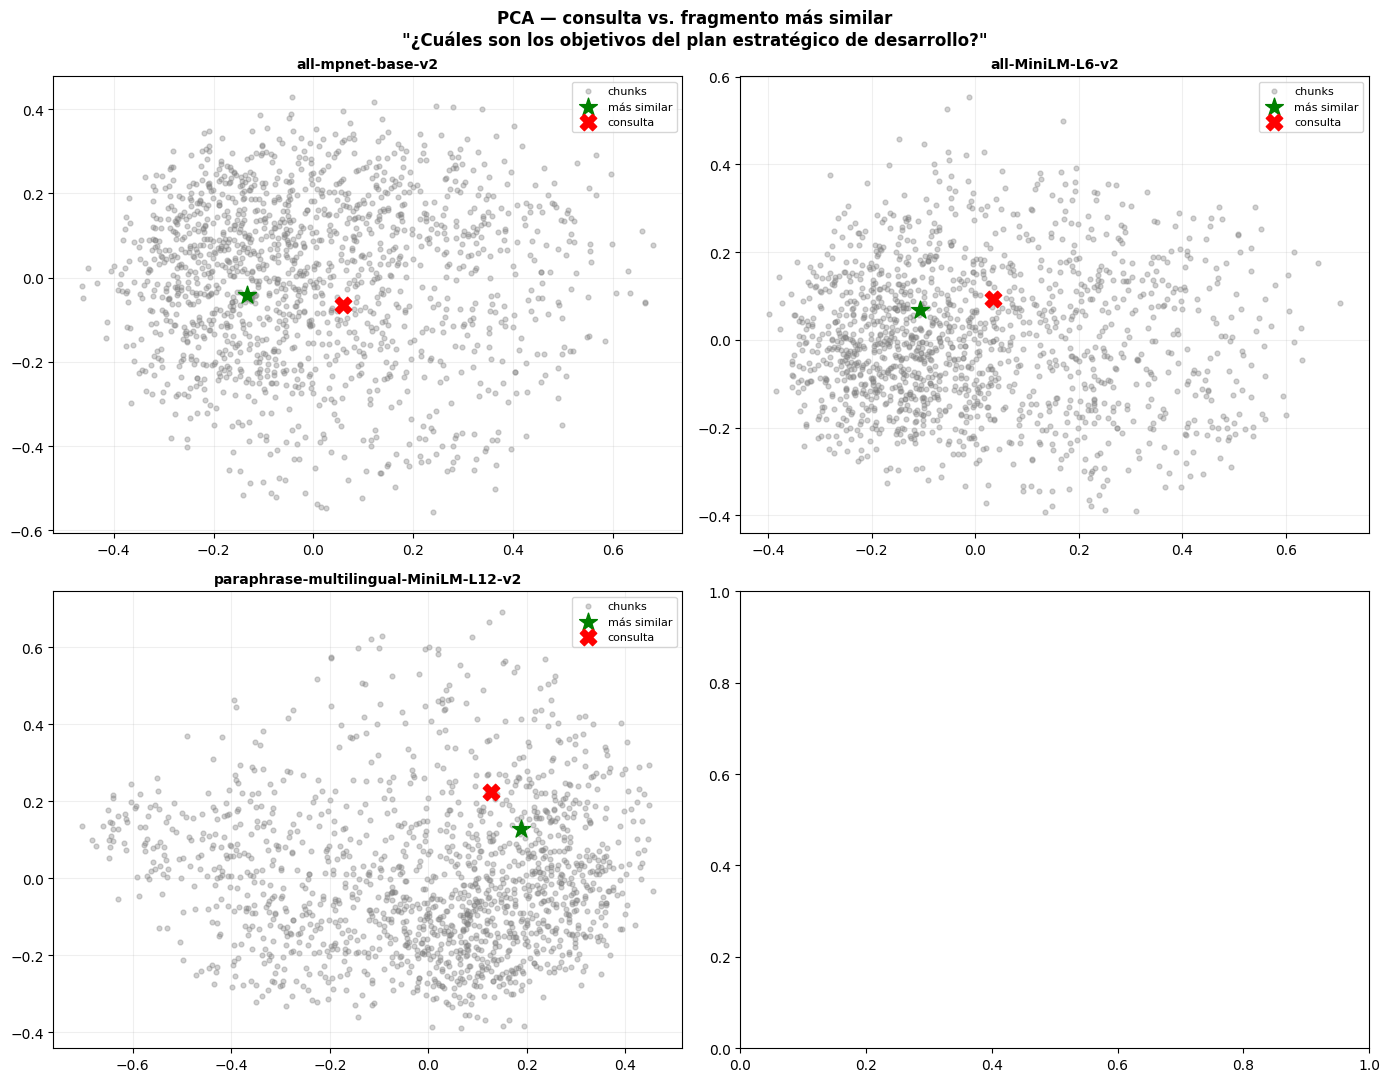

In [19]:
# 3.5  PCA por modelo: consulta (rojo) + fragmento más similar (verde), sobre el espacio de chunks
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
for ax, (nombre, (modelo, emb)) in zip(axes.ravel(), emb_por_modelo.items()):
    q = modelo.encode([consulta], convert_to_numpy=True, normalize_embeddings=True)
    todos = np.vstack([emb, q])                      # chunks + consulta
    coords = PCA(n_components=2, random_state=42).fit_transform(todos)
    chunk_xy, q_xy = coords[:-1], coords[-1]
    idx = resultados_top[nombre][0]

    ax.scatter(chunk_xy[:, 0], chunk_xy[:, 1], s=12, alpha=.35, color='gray', label='chunks')
    ax.scatter(*chunk_xy[idx], s=180, color='green', marker='*', label='más similar')
    ax.scatter(*q_xy, s=140, color='red', marker='X', label='consulta')
    ax.set_title(nombre.split('/')[-1], fontweight='bold', fontsize=10)
    ax.legend(fontsize=8); ax.grid(alpha=.2)

plt.suptitle(f'PCA — consulta vs. fragmento más similar\n"{consulta}"', fontweight='bold')
plt.tight_layout(); plt.show()

## Conclusiones

- **Punto 1:** FastText maneja mejor la morfología del español y palabras OOV gracias a los
  n-gramas de caracteres; Word2Vec es más ligero. La visualización PCA muestra cómo se agrupan
  las palabras según cada modelo al aumentar el número de sentencias.
- **Punto 2:** el dataset BioBERT se carga con su script; BETO tokeniza en **subpalabras**
  (`##`), por lo que una palabra puede generar varios subtokens (importante al alinear etiquetas
  NER).
- **Punto 3:** los modelos multilingües (`bge-m3`, `paraphrase-multilingual`) suelen recuperar
  mejor en español; `all-mpnet-base-v2` da alta precisión en inglés. La similitud coseno + PCA
  permiten ver qué fragmento recupera cada modelo para la misma consulta.